# 01 — Data Overview

Exploratory analysis of the historical order-demand dataset: structure, data types, trends, seasonality, and demand distribution.

## 1. Setup & Imports

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("../data/raw/demand.csv")

In [3]:
print("Shape: ", df.shape)
print("Columns: ", df.columns.tolist())

Shape:  (1048575, 5)
Columns:  ['Product_Code', 'Warehouse', 'Product_Category', 'Date', 'Order_Demand']


In [4]:
df.head()

,Product_Code,Warehouse,Product_Category,Date,Order_Demand
0,Product_0993,Whse_J,Category_028,2012/7/27,100
1,Product_0979,Whse_J,Category_028,2012/1/19,500
2,Product_0979,Whse_J,Category_028,2012/2/3,500
3,Product_0979,Whse_J,Category_028,2012/2/9,500
4,Product_0979,Whse_J,Category_028,2012/3/2,500


In [5]:
df["Date"] = pd.to_datetime(df["Date"])

In [6]:
df.dtypes

Product_Code                object
Warehouse                   object
Product_Category            object
Date                datetime64[ns]
Order_Demand                object
dtype: object

In [7]:
df.isnull().sum

<bound method DataFrame.sum of          Product_Code  Warehouse  Product_Category   Date  Order_Demand
0               False      False             False  False         False
1               False      False             False  False         False
2               False      False             False  False         False
3               False      False             False  False         False
4               False      False             False  False         False
...               ...        ...               ...    ...           ...
1048570         False      False             False  False         False
1048571         False      False             False  False         False
1048572         False      False             False  False         False
1048573         False      False             False  False         False
1048574         False      False             False  False         False

[1048575 rows x 5 columns]>

## Granularity & Structure Analysis

In [8]:
print("Date Range: ")
print(df["Date"].min(), "to", df["Date"].max())

print("\nUnique warehouses: ", df["Warehouse"].nunique())
print("\nUnique products: ", df["Product_Code"].nunique())
print("\nUnique product catagories: ", df["Product_Category"].nunique())

date_diff = df["Date"].sort_values().diff().dropna()
print("\nMost common difference between consecutive dates: ")
print(date_diff.value_counts().head())

Date Range: 
2011-01-08 00:00:00 to 2017-01-09 00:00:00

Unique warehouses:  4

Unique products:  2160

Unique product catagories:  33

Most common difference between consecutive dates: 
Date
0 days     1035607
1 days        1575
2 days         128
3 days          17
70 days          1
Name: count, dtype: int64


## Trend & Aggregation Analysis

In [9]:
#Daily Aggregation of total demand

df["Order_Demand"] = (df["Order_Demand"]
                      .astype(str)
                      .str.replace(",","",regex = False)
                     )
df["Order_Demand"] = pd.to_numeric(df["Order_Demand"], errors = "coerce")
df["Order_Demand"].dtype

daily_demand = (
    df.groupby("Date", as_index = False)["Order_Demand"]
    .sum()
)

daily_demand.head()

,Date,Order_Demand
0,2011-01-08,2.0
1,2011-05-31,108.0
2,2011-06-24,92000.0
3,2011-09-02,1250.0
4,2011-09-27,28.0


C:\Users\dell\AppData\Local\Temp\ipykernel_10540\1909625452.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")["Order_Demand"]


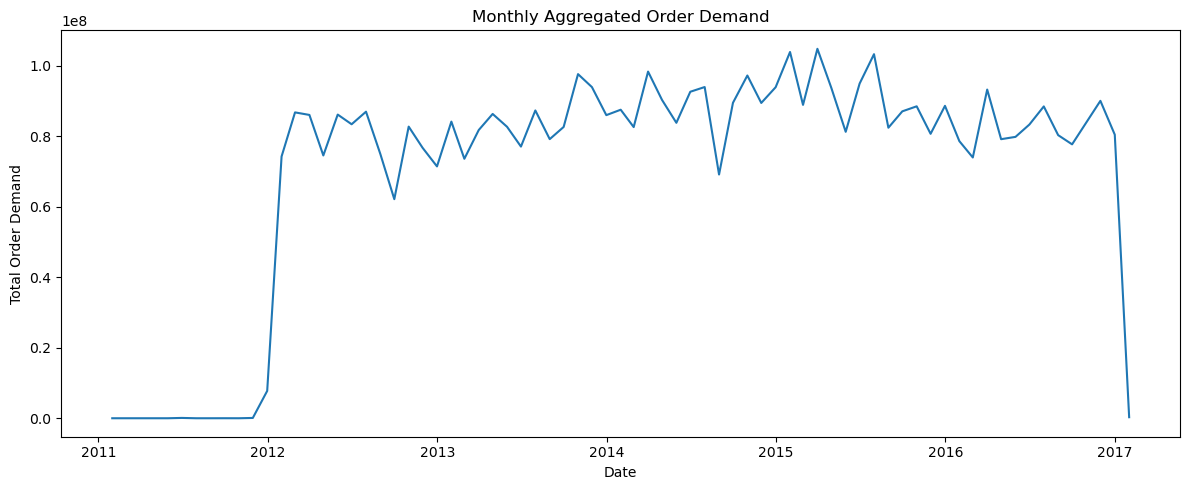

In [10]:
import matplotlib.pyplot as plt

#Monthly aggregation + plot

monthly_demand = (
    df.set_index("Date")
    .resample("M")["Order_Demand"]
    .sum()
    .reset_index()
)

plt.figure(figsize = (12,5))
plt.plot(monthly_demand["Date"], monthly_demand["Order_Demand"])
plt.title("Monthly Aggregated Order Demand")
plt.xlabel("Date")
plt.ylabel("Total Order Demand")
plt.tight_layout()
plt.show()

## Seasonality Analysis

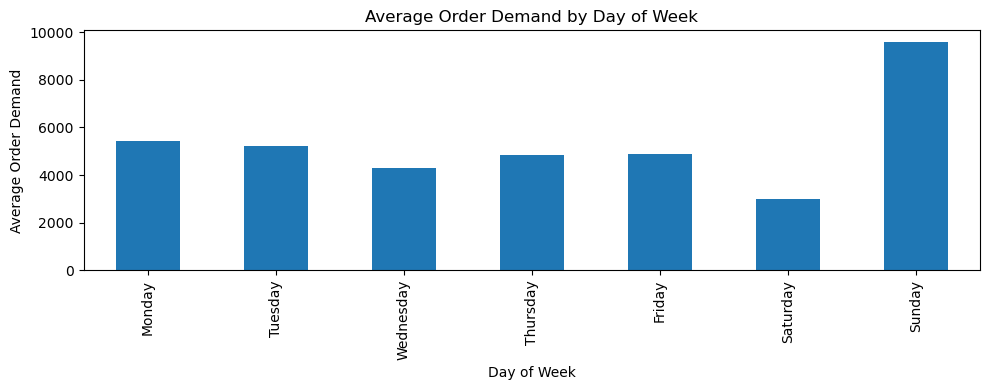

In [11]:
#day of the week seasonality

df["day_of_the_week"] = df["Date"].dt.day_name()

dow_demand = (
    df.groupby("day_of_the_week")["Order_Demand"]
    .mean()
    .reindex(["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"])
)

plt.figure(figsize = (10,4))
dow_demand.plot(kind = "bar")
plt.title("Average Order Demand by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Order Demand")
plt.tight_layout()
plt.show()

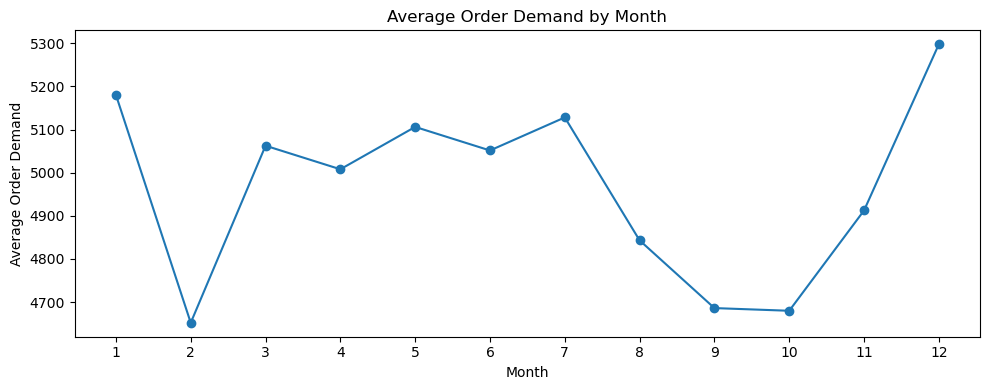

In [12]:
#month of year seasonality

df["month"] = df["Date"].dt.month

moy_demand = (
    df.groupby("month")["Order_Demand"]
    .mean()
)

plt.figure(figsize = (10,4))
plt.plot(moy_demand.index, moy_demand.values, marker="o")
plt.title("Average Order Demand by Month")
plt.xlabel("Month")
plt.ylabel("Average Order Demand")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

## Distribution & Variability Analysis

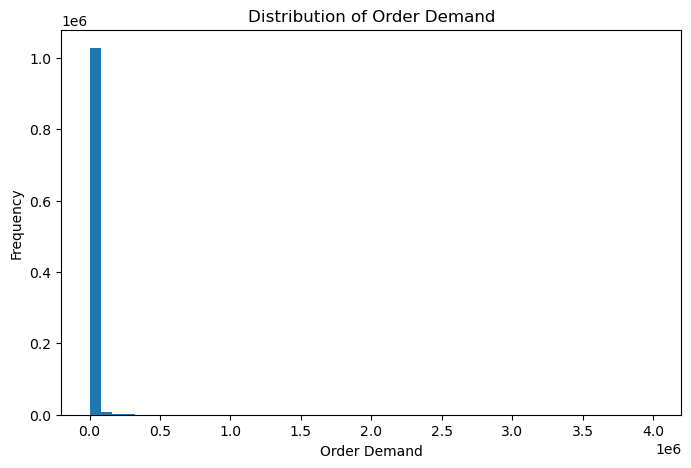

In [13]:
#Distribution of Demand
plt.figure(figsize = (8,5))
plt.hist(df["Order_Demand"], bins = 50)
plt.title("Distribution of Order Demand")
plt.xlabel("Order Demand")
plt.ylabel("Frequency")
plt.show()

In [14]:
#Zero Demand Frequency

zero_demand = (df["Order_Demand"] == 0).sum()
total = len(df)

print("Zero Demand Count: ", zero_demand)
print("Zero Demand Percentage: ",round((zero_demand / total)*100,2), "%")

Zero Demand Count:  28681
Zero Demand Percentage:  2.74 %


In [15]:
#High vs Low Demand Product

product_avg = (
    df.groupby("Product_Code")["Order_Demand"]
    .mean()
    .sort_values(ascending = False)
)
high_demand = product_avg.index[0]
low_demand = product_avg.index[-1]
print("High demand product: ", high_demand)
print("Low demand product: ", low_demand)

High demand product:  Product_1245
Low demand product:  Product_1698


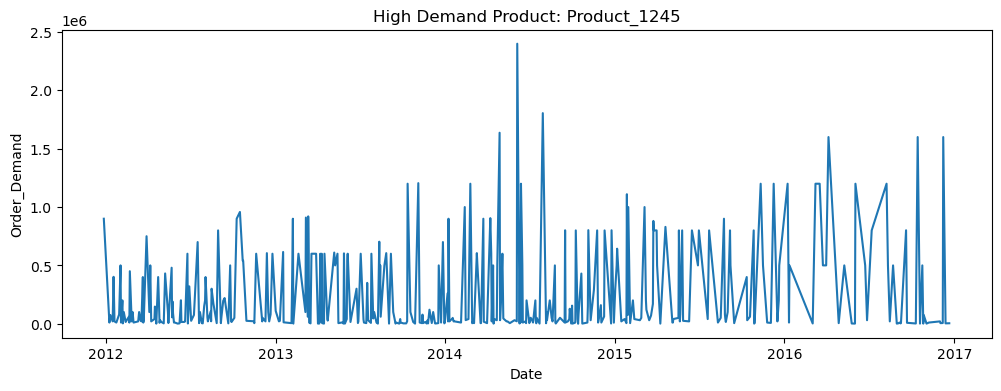

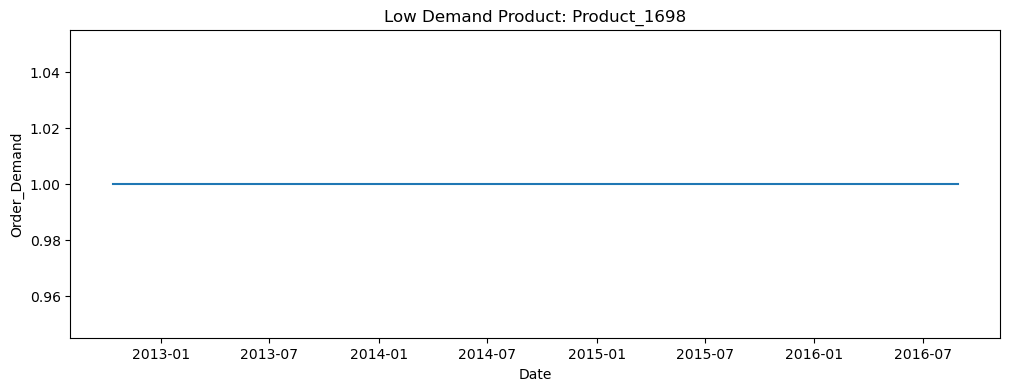

In [16]:
#Time series comparision

high_df = (
    df[df["Product_Code"] == high_demand]
    .groupby(["Date"],as_index = False)["Order_Demand"]
    .sum()
)
low_df = (
    df[df["Product_Code"] == low_demand]
    .groupby(["Date"],as_index = False)["Order_Demand"]
    .sum()
)

plt.figure(figsize = (12,4))
plt.plot(high_df["Date"], high_df["Order_Demand"])
plt.title(f"High Demand Product: {high_demand}")
plt.xlabel("Date")
plt.ylabel("Order_Demand")
plt.show()

plt.figure(figsize = (12,4))
plt.plot(low_df["Date"], low_df["Order_Demand"])
plt.title(f"Low Demand Product: {low_demand}")
plt.xlabel("Date")
plt.ylabel("Order_Demand")
plt.show()